# Experimento final: N-BEATS vs baselines secuenciales

Este notebook consolida el protocolo experimental para el paper IBERAMIA.

La pregunta central es:

> Vale la pena utilizar un modelo de deep learning como N-BEATS para la prediccion secuencial del nivel del Arroyo Mburicao, o baselines secuenciales simples ya son suficientes?

Para responder esto, todos los modelos se evaluan bajo el mismo protocolo:

- mismos datasets 2021 y 2025;
- misma separacion por segmentos;
- split cronologico `train / validation / test` dentro de cada segmento;
- seleccion de configuracion sobre validacion;
- metricas principales reportadas solamente sobre test;
- mismo horizonte maximo de 30 minutos;
- mismos lead times: `t+10`, `t+20`, `t+30`;
- mismas condiciones criticas: lluvia, lluvia acumulada 1h alta, nivel alto y subida rapida;
- mismas metricas.


## Notebooks de origen

Este notebook integra la evidencia de:

| Notebook | Uso |
|---|---|
| `08_nbeats_listas.ipynb` | Metodo N-BEATS con listas de series. |
| `09_nbeats_gridsearch.ipynb` | Seleccion de hiperparametros de N-BEATS. |
| `10_correlacion_dinamica_2021_2025.ipynb` | Justificacion hidrologica del horizonte corto. |
| `14_nbeats_vs_baselines_secuenciales.ipynb` | Diseno de baselines secuenciales. |

El notebook 10 muestra que la maxima asociacion estadistica lluvia-respuesta ocurre aproximadamente entre 20 y 30 minutos. Por eso, `t+30 min` es el horizonte principal para interpretar utilidad hidrologica.


In [1]:
# Si Darts no esta instalado en el entorno, ejecutar una vez:
# %pip install "u8darts[torch]" scikit-learn

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import NBEATSModel

warnings.filterwarnings("ignore")

try:
    import torch
    torch.set_float32_matmul_precision("medium")
except Exception as exc:
    print(f"No se pudo configurar torch.set_float32_matmul_precision: {exc}")


/home/federico.moran/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Configuracion experimental comun

Los datos estan a frecuencia de 10 minutos. Se evalua un horizonte maximo de 30 minutos:

```text
FORECAST_HORIZON = 3 pasos = 30 minutos
```

Cada prediccion multi-step genera tres errores separados:

```text
lead 1 -> t+10 min
lead 2 -> t+20 min
lead 3 -> t+30 min
```

El paper debe mirar especialmente `t+30 min`, porque es el horizonte mas alineado con la dinamica lluvia-nivel observada.


In [3]:
# Columnas del dataset
TIME_COL = "Time"
TARGET_COL = "Nivel"
RAIN_COL = "Precipitacion"

# Frecuencia temporal
FREQ = "10min"
FREQ_DELTA = pd.Timedelta(minutes=10)
STEPS_PER_HOUR = 6

# Horizonte principal: 30 minutos
FORECAST_HORIZON = 3

# Protocolo comun de evaluacion.
# EVAL_STRIDE=1 genera predicciones en cada origen posible del set de test.
EVAL_STRIDE = 1

# Split temporal por segmento.
# Train: ajuste de modelos.
# Validation: seleccion de configuracion/hiperparametros.
# Test: metricas finales del paper.
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 1.0 - TRAIN_FRACTION - VAL_FRACTION

# Baselines locales
MOVING_AVERAGE_WINDOWS = {
    "Media_movil_30min": 3,
    "Media_movil_60min": 6,
    "Media_movil_90min": 9,
}

DRIFT_WINDOWS = {
    "Drift_30min": 3,
    "Drift_60min": 6,
    "Drift_90min": 9,
}

# Ridge-ARX
RIDGE_ALPHA = 1.0

# N-BEATS: mejor configuracion del grid search preliminar
RUN_NBEATS = True
LOAD_NBEATS_FROM_CHECKPOINT = False
NBEATS_INPUT_CHUNK_LENGTH = 72
NBEATS_EPOCHS = 30
NBEATS_BATCH_SIZE = 1024
NBEATS_MODEL_NAME = "15_nbeats_vs_baselines_final_in72_h3"
RANDOM_STATE = 42

# Graficos
ZOOM_HOURS_BEFORE = 6
ZOOM_HOURS_AFTER = 12

print("Split:")
print(f"Train: {TRAIN_FRACTION:.0%}")
print(f"Validation: {VAL_FRACTION:.0%}")
print(f"Test: {TEST_FRACTION:.0%}")

print("\nLead times evaluados:")
for step in range(1, FORECAST_HORIZON + 1):
    print(f"lead_step={step}: t+{step * 10} min")


Split:
Train: 70%
Validation: 15%
Test: 15%

Lead times evaluados:
lead_step=1: t+10 min
lead_step=2: t+20 min
lead_step=3: t+30 min


## Rutas del proyecto

La celda siguiente intenta resolver las rutas tanto en la PC local como en el servidor. No se usa `pathlib`, para mantener compatibilidad con tus notebooks anteriores.


In [4]:
def resolve_project_dir():
    cwd = os.getcwd()
    candidates = [
        cwd,
        os.path.dirname(cwd),
        os.path.join(cwd, "Mburicao_Iberamia"),
        os.path.join(os.path.dirname(cwd), "Mburicao_Iberamia"),
        r"G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia",
        "/data/students/federico.moran",
        "/data/students/federico.moran/notebooks",
    ]

    for candidate in candidates:
        if not candidate:
            continue
        if os.path.exists(os.path.join(candidate, "notebooks")) or os.path.exists(os.path.join(candidate, "data")):
            return os.path.abspath(candidate)

    return os.path.abspath(cwd)


PROJECT_DIR = resolve_project_dir()

FIGURES_DIR = os.path.join(PROJECT_DIR, "figures", "15_nbeats_vs_baselines_final")
MODELS_DIR = os.path.join(PROJECT_DIR, "models", "15_nbeats_vs_baselines_final")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


def find_csv(filename):
    candidates = [
        os.path.join(PROJECT_DIR, "data", "processed", "datos_lluvia_nivel", filename),
        os.path.join(PROJECT_DIR, "datasets", "datos_lluvia_nivel", filename),
        os.path.join(os.path.dirname(PROJECT_DIR), "datasets", "datos_lluvia_nivel", filename),
        os.path.join("/data/students/federico.moran", "datasets", "datos_lluvia_nivel", filename),
        os.path.join("/data/students/federico.moran", "notebooks", "datasets", "datos_lluvia_nivel", filename),
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    raise FileNotFoundError("No se encontro el archivo: " + filename + "\nCandidatos:\n" + "\n".join(candidates))


CSV_PATHS = {
    "2021": find_csv("Mburicao_2021.csv"),
    "2025": find_csv("Mburicao_2025.csv"),
}

print("PROJECT_DIR:", PROJECT_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("CSV encontrados:")
for segment_name, path in CSV_PATHS.items():
    print(segment_name, "->", path)


PROJECT_DIR: /data/students/federico.moran
FIGURES_DIR: /data/students/federico.moran/figures/15_nbeats_vs_baselines_final
MODELS_DIR: /data/students/federico.moran/models/15_nbeats_vs_baselines_final
REPORTS_DIR: /data/students/federico.moran/reports
CSV encontrados:
2021 -> /data/students/federico.moran/datasets/datos_lluvia_nivel/Mburicao_2021.csv
2025 -> /data/students/federico.moran/datasets/datos_lluvia_nivel/Mburicao_2025.csv


## Evidencia hidrologica del horizonte de 30 minutos

Si existe el archivo `10_resumen_de_indicadores.csv`, se carga para dejar dentro del notebook final la justificacion del horizonte corto.

Los valores esperados son:

- rezago maximo 2021: alrededor de 20 minutos;
- rezago maximo 2025: alrededor de 30 minutos.

Esto no significa que todos los eventos tengan su pico exactamente a los 30 minutos, sino que la asociacion estadistica lluvia-subida de nivel es maxima en ese rango.


In [5]:
indicators_path = os.path.join(REPORTS_DIR, "10_resumen_de_indicadores.csv")

if os.path.exists(indicators_path):
    indicators_df = pd.read_csv(indicators_path)
    display(indicators_df)

    lag_2021 = indicators_df.loc[indicators_df["indicador"] == "rezago_max_respuesta_2021_horas", "valor"]
    lag_2025 = indicators_df.loc[indicators_df["indicador"] == "rezago_max_respuesta_2025_horas", "valor"]

    if len(lag_2021) and len(lag_2025):
        lag_2021_min = float(lag_2021.iloc[0]) * 60
        lag_2025_min = float(lag_2025.iloc[0]) * 60
        print(f"Rezago maximo 2021: {lag_2021_min:.1f} min")
        print(f"Rezago maximo 2025: {lag_2025_min:.1f} min")
else:
    print("No se encontro 10_resumen_de_indicadores.csv. Se puede ejecutar el notebook 10 para generarlo.")


No se encontro 10_resumen_de_indicadores.csv. Se puede ejecutar el notebook 10 para generarlo.


## Carga y preprocesamiento por segmento

Cada periodo se carga y regulariza de forma independiente. Esto evita crear muestras artificiales en el hueco temporal entre las campanas 2021 y 2025.


In [6]:
def load_segment(csv_path, segment_name):
    df = pd.read_csv(csv_path)

    required_columns = {TIME_COL, TARGET_COL, RAIN_COL}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltan columnas requeridas en {csv_path}: {sorted(missing_columns)}")

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])
    df = df.sort_values(TIME_COL)
    df = df.set_index(TIME_COL)
    df = df[~df.index.duplicated(keep="first")]

    df = df[[TARGET_COL, RAIN_COL]].copy()
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df[RAIN_COL] = pd.to_numeric(df[RAIN_COL], errors="coerce")

    df = df.asfreq(FREQ)
    df[TARGET_COL] = df[TARGET_COL].interpolate(method="time").ffill().bfill()
    df[RAIN_COL] = df[RAIN_COL].fillna(0.0)
    df["segmento"] = segment_name

    return df


segments = {}
for segment_name, csv_path in CSV_PATHS.items():
    segments[segment_name] = load_segment(csv_path, segment_name)

segment_names = list(segments.keys())

summary_rows = []
for segment_name, df_segment in segments.items():
    summary_rows.append({
        "segmento": segment_name,
        "filas": len(df_segment),
        "inicio": df_segment.index.min(),
        "fin": df_segment.index.max(),
        "freq_inferida": pd.infer_freq(df_segment.index),
        "nivel_min": df_segment[TARGET_COL].min(),
        "nivel_max": df_segment[TARGET_COL].max(),
        "lluvia_total": df_segment[RAIN_COL].sum(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_path = os.path.join(REPORTS_DIR, "15_dataset_resumen.csv")
summary_df.to_csv(summary_path, index=False)
print("Resumen guardado en:", summary_path)


,segmento,filas,inicio,fin,freq_inferida,nivel_min,nivel_max,lluvia_total
0,2021,42220,2021-06-12 12:00:00,2022-04-01 16:30:00,10min,0.030263,3.746,741.6
1,2025,29055,2025-08-27 15:10:00,2026-03-17 09:30:00,10min,0.400000,3.300,317.2


Resumen guardado en: /data/students/federico.moran/reports/15_dataset_resumen.csv


## Split temporal comun

Cada segmento se divide cronologicamente en tres partes:

```text
70% entrenamiento
15% validacion
15% test
```

El rol de cada subconjunto es distinto:

- **Entrenamiento:** ajustar Ridge-ARX y N-BEATS.
- **Validacion:** seleccionar configuraciones e hiperparametros.
- **Test:** calcular las metricas finales que se reportaran en el paper.

Las tablas principales de este notebook se calculan sobre el set de test.


In [7]:
split_info = {}

for segment_name in segment_names:
    df_segment = segments[segment_name]
    n = len(df_segment)

    train_end_position = int(n * TRAIN_FRACTION)
    val_end_position = int(n * (TRAIN_FRACTION + VAL_FRACTION))

    min_history = max(
        max(MOVING_AVERAGE_WINDOWS.values()),
        max(DRIFT_WINDOWS.values()),
        NBEATS_INPUT_CHUNK_LENGTH,
        FORECAST_HORIZON + 1,
    )

    # Se asegura historia suficiente para entrenar/evaluar y espacio para predecir.
    train_end_position = max(train_end_position, min_history + FORECAST_HORIZON + 1)
    val_end_position = max(val_end_position, train_end_position + FORECAST_HORIZON + 1)
    val_end_position = min(val_end_position, n - FORECAST_HORIZON - 1)

    train_end_time = df_segment.index[train_end_position]
    test_start_time = df_segment.index[val_end_position]

    split_info[segment_name] = {
        "train_end_position": train_end_position,
        "val_end_position": val_end_position,
        "test_start_position": val_end_position,
        "train_end_time": train_end_time,
        "test_start_time": test_start_time,
        "train_points": train_end_position,
        "val_points": val_end_position - train_end_position,
        "test_points": n - val_end_position,
    }

split_df = pd.DataFrame([
    {
        "segmento": segment_name,
        "train_end_position": info["train_end_position"],
        "val_end_position": info["val_end_position"],
        "train_end_time": info["train_end_time"],
        "test_start_time": info["test_start_time"],
        "train_points": info["train_points"],
        "val_points": info["val_points"],
        "test_points": info["test_points"],
    }
    for segment_name, info in split_info.items()
])

display(split_df)

split_path = os.path.join(REPORTS_DIR, "15_split_resumen.csv")
split_df.to_csv(split_path, index=False)
print("Split guardado en:", split_path)


,segmento,train_end_position,val_end_position,train_end_time,test_start_time,train_points,val_points,test_points
0,2021,29553,35887,2022-01-03 17:30:00,2022-02-16 17:10:00,29553,6334,6333
1,2025,20338,24696,2026-01-15 20:50:00,2026-02-15 03:10:00,20338,4358,4359


Split guardado en: /data/students/federico.moran/reports/15_split_resumen.csv


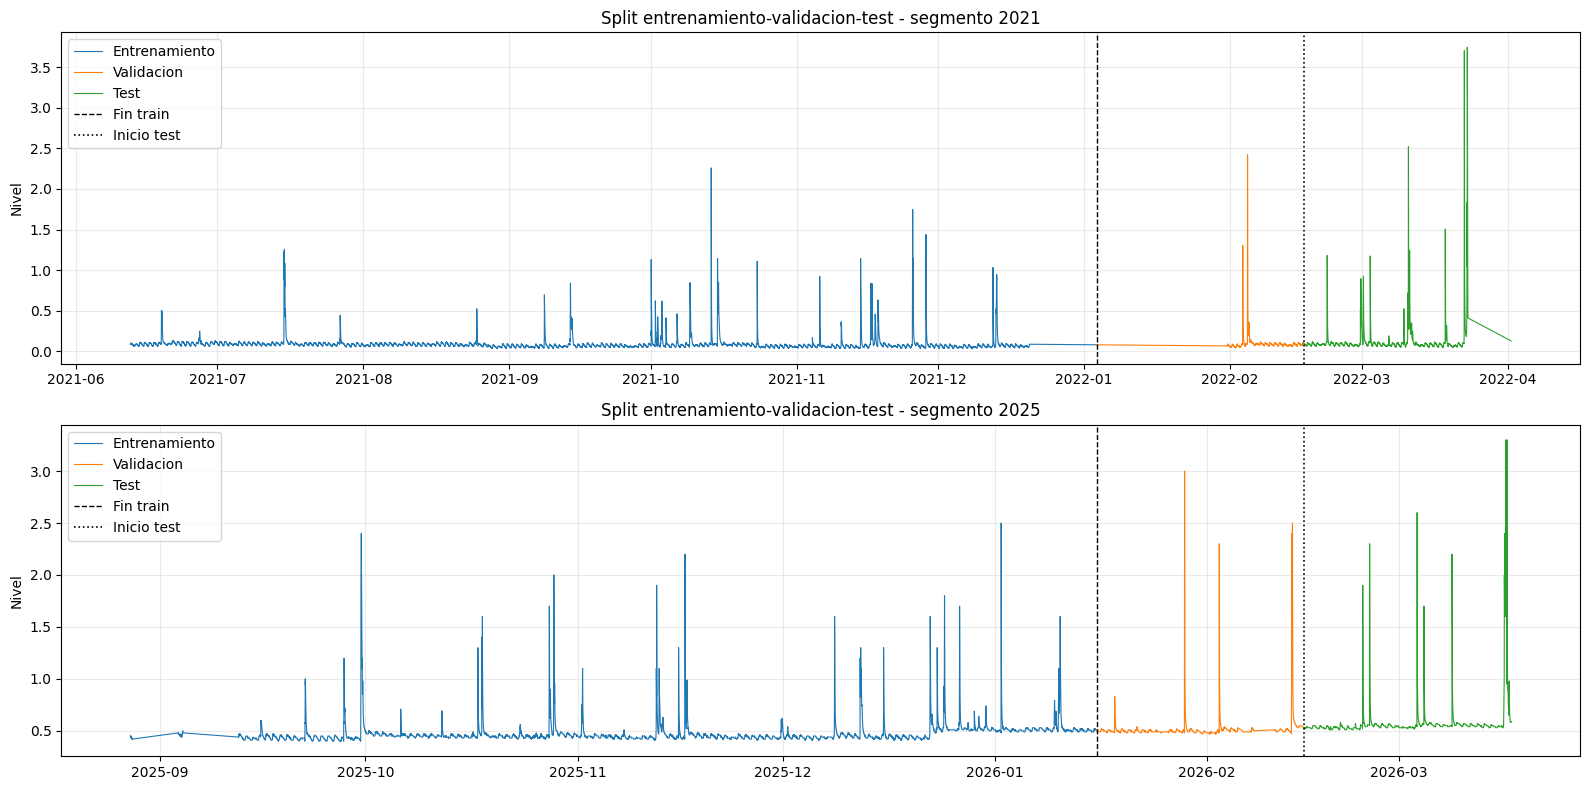

In [8]:
fig, axes = plt.subplots(len(segment_names), 1, figsize=(16, 4 * len(segment_names)), sharex=False)
if len(segment_names) == 1:
    axes = [axes]

for ax, segment_name in zip(axes, segment_names):
    df_segment = segments[segment_name]
    train_end_time = split_info[segment_name]["train_end_time"]
    test_start_time = split_info[segment_name]["test_start_time"]

    train_df = df_segment.loc[df_segment.index < train_end_time]
    val_df = df_segment.loc[(df_segment.index >= train_end_time) & (df_segment.index < test_start_time)]
    test_df = df_segment.loc[df_segment.index >= test_start_time]

    ax.plot(train_df.index, train_df[TARGET_COL], label="Entrenamiento", color="tab:blue", linewidth=0.8)
    ax.plot(val_df.index, val_df[TARGET_COL], label="Validacion", color="tab:orange", linewidth=0.8)
    ax.plot(test_df.index, test_df[TARGET_COL], label="Test", color="tab:green", linewidth=0.8)

    ax.axvline(train_end_time, color="black", linestyle="--", linewidth=1, label="Fin train")
    ax.axvline(test_start_time, color="black", linestyle=":", linewidth=1.2, label="Inicio test")

    ax.set_title(f"Split entrenamiento-validacion-test - segmento {segment_name}")
    ax.set_ylabel("Nivel")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "01_split_train_val_test_por_segmento.png"), dpi=180, bbox_inches="tight")
plt.show()


## Utilidades para predicciones y metricas

Todas las predicciones se guardan en formato largo:

| columna | significado |
|---|---|
| `modelo` | nombre del modelo |
| `segmento` | 2021 o 2025 |
| `origin_time` | ultimo instante observado antes de emitir la prediccion |
| `pred_time` | instante futuro predicho |
| `lead_minutes` | horizonte en minutos |
| `pred` | valor predicho |
| `actual` | valor observado |

Este formato permite calcular metricas globales, por segmento, por lead time y por condicion critica.


In [9]:
EPS = 1e-8


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "MAPE (%)": np.nan,
            "sMAPE (%)": np.nan,
            "Bias": np.nan,
            "NSE": np.nan,
        }

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    if len(np.unique(y_true)) > 1:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    valid_mape = np.abs(y_true) > EPS
    if valid_mape.any():
        mape = np.mean(np.abs((y_true[valid_mape] - y_pred[valid_mape]) / y_true[valid_mape])) * 100
    else:
        mape = np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid_smape = smape_denom > EPS
    if valid_smape.any():
        smape = np.mean(np.abs(y_true[valid_smape] - y_pred[valid_smape]) / smape_denom[valid_smape]) * 100
    else:
        smape = np.nan

    bias = np.mean(y_pred - y_true)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / denominator if denominator > EPS else np.nan

    return {
        "n": len(y_true),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "Bias": bias,
        "NSE": nse,
    }


def context_for_segment(segment_name):
    df_segment = segments[segment_name]
    context = df_segment[[TARGET_COL, RAIN_COL]].copy()
    context["lluvia_1h"] = context[RAIN_COL].rolling(STEPS_PER_HOUR, min_periods=1).sum()
    context["delta_nivel"] = context[TARGET_COL].diff()
    context = context.rename(columns={TARGET_COL: "actual"})
    context["pred_time"] = context.index
    return context


def enrich_prediction_rows(segment_name, model_name, rows):
    pred_df = pd.DataFrame(rows)
    if pred_df.empty:
        return pred_df

    context = context_for_segment(segment_name)

    pred_df["segmento"] = segment_name
    pred_df["modelo"] = model_name
    pred_df = pred_df.merge(
        context[["pred_time", "actual", RAIN_COL, "lluvia_1h", "delta_nivel"]],
        on="pred_time",
        how="left",
    )

    return pred_df.dropna(subset=["actual", "pred"]).reset_index(drop=True)


predictions = {}


def store_prediction(model_name, segment_name, pred_df):
    predictions[(model_name, segment_name)] = pred_df
    return pred_df


## Baselines secuenciales

Se evaluan cuatro familias de baselines:

1. **Persistencia:** el nivel futuro es igual al ultimo nivel observado.
2. **Media movil:** el nivel futuro es el promedio reciente.
3. **Drift local:** extrapola la pendiente reciente.
4. **Ridge-ARX local:** modelo lineal entrenable con nivel reciente, deltas y lluvia reciente.

Estos modelos son importantes porque N-BEATS solo se justifica si mejora a referencias fuertes y simples.


In [10]:
def make_simple_baseline_prediction(segment_name, method, window_steps=None):
    df_segment = segments[segment_name]
    test_start_position = split_info[segment_name]["test_start_position"]
    values = df_segment[TARGET_COL].values.astype(float)
    time_index = df_segment.index

    rows = []
    first_origin = max(test_start_position, int(window_steps or 1))
    last_origin = len(df_segment) - FORECAST_HORIZON

    for origin in range(first_origin, last_origin + 1, EVAL_STRIDE):
        history = values[:origin]
        origin_time = time_index[origin - 1]

        if method == "Persistencia":
            forecast = np.repeat(history[-1], FORECAST_HORIZON)

        elif method.startswith("Media_movil"):
            window = int(window_steps)
            forecast_value = np.mean(history[-window:]) if len(history) >= window else np.mean(history)
            forecast = np.repeat(forecast_value, FORECAST_HORIZON)

        elif method.startswith("Drift"):
            window = int(window_steps)
            if len(history) > window:
                slope = (history[-1] - history[-1 - window]) / window
            elif len(history) > 1:
                slope = history[-1] - history[-2]
            else:
                slope = 0.0

            forecast = history[-1] + slope * np.arange(1, FORECAST_HORIZON + 1)

        else:
            raise ValueError("Metodo no reconocido: " + method)

        for lead_step in range(1, FORECAST_HORIZON + 1):
            pred_index = origin + lead_step - 1
            rows.append({
                "origin_time": origin_time,
                "pred_time": time_index[pred_index],
                "lead_step": lead_step,
                "lead_minutes": lead_step * 10,
                "pred": forecast[lead_step - 1],
            })

    pred_df = enrich_prediction_rows(segment_name, method, rows)
    return pred_df


for segment_name in segment_names:
    pred_df = make_simple_baseline_prediction(segment_name, "Persistencia", window_steps=1)
    store_prediction("Persistencia", segment_name, pred_df)

for model_name, window_steps in MOVING_AVERAGE_WINDOWS.items():
    for segment_name in segment_names:
        pred_df = make_simple_baseline_prediction(segment_name, model_name, window_steps=window_steps)
        store_prediction(model_name, segment_name, pred_df)

for model_name, window_steps in DRIFT_WINDOWS.items():
    for segment_name in segment_names:
        pred_df = make_simple_baseline_prediction(segment_name, model_name, window_steps=window_steps)
        store_prediction(model_name, segment_name, pred_df)

print("Baselines simples calculados:")
for key, pred_df in predictions.items():
    print(key, len(pred_df))


Baselines simples calculados:
('Persistencia', '2021') 18993
('Persistencia', '2025') 13071
('Media_movil_30min', '2021') 18993
('Media_movil_30min', '2025') 13071
('Media_movil_60min', '2021') 18993
('Media_movil_60min', '2025') 13071
('Media_movil_90min', '2021') 18993
('Media_movil_90min', '2025') 13071
('Drift_30min', '2021') 18993
('Drift_30min', '2025') 13071
('Drift_60min', '2021') 18993
('Drift_60min', '2025') 13071
('Drift_90min', '2021') 18993
('Drift_90min', '2025') 13071


## Ridge-ARX local

Ridge-ARX es un baseline entrenable:

```text
AR = autoregresivo, usa historia del propio nivel
X  = exogeno, usa lluvia reciente
```

Predice simultaneamente:

```text
[Nivel(t+10), Nivel(t+20), Nivel(t+30)]
```

Su rol en el paper es muy importante: si Ridge-ARX se acerca a N-BEATS, entonces puede que un modelo lineal interpretable ya sea suficiente.


In [11]:
def safe_slice(values, start, end):
    start = max(0, start)
    end = max(start, end)
    return values[start:end]


def mean_or_last(values, fallback):
    if len(values) == 0:
        return fallback
    return float(np.mean(values))


def sum_or_zero(values):
    if len(values) == 0:
        return 0.0
    return float(np.sum(values))


def max_or_zero(values):
    if len(values) == 0:
        return 0.0
    return float(np.max(values))


def make_arx_features(df_segment, origin):
    y = df_segment[TARGET_COL].values.astype(float)
    rain = df_segment[RAIN_COL].values.astype(float)
    timestamp = df_segment.index[origin - 1]

    last_level = y[origin - 1]

    def lag_delta(steps):
        if origin > steps:
            return last_level - y[origin - 1 - steps]
        return 0.0

    level_30m = safe_slice(y, origin - 3, origin)
    level_60m = safe_slice(y, origin - 6, origin)
    level_90m = safe_slice(y, origin - 9, origin)

    rain_10m = safe_slice(rain, origin - 1, origin)
    rain_30m = safe_slice(rain, origin - 3, origin)
    rain_60m = safe_slice(rain, origin - 6, origin)
    rain_90m = safe_slice(rain, origin - 9, origin)

    hour = timestamp.hour + timestamp.minute / 60
    hour_angle = 2 * np.pi * hour / 24

    return np.array([
        last_level,
        lag_delta(1),
        lag_delta(2),
        lag_delta(3),
        lag_delta(6),
        lag_delta(9),
        mean_or_last(level_30m, last_level),
        mean_or_last(level_60m, last_level),
        mean_or_last(level_90m, last_level),
        sum_or_zero(rain_10m),
        sum_or_zero(rain_30m),
        sum_or_zero(rain_60m),
        sum_or_zero(rain_90m),
        max_or_zero(rain_30m),
        max_or_zero(rain_60m),
        max_or_zero(rain_90m),
        np.sin(hour_angle),
        np.cos(hour_angle),
    ], dtype=float)


FEATURE_NAMES = [
    "nivel_t",
    "delta_10m",
    "delta_20m",
    "delta_30m",
    "delta_60m",
    "delta_90m",
    "nivel_media_30m",
    "nivel_media_60m",
    "nivel_media_90m",
    "lluvia_10m",
    "lluvia_30m",
    "lluvia_60m",
    "lluvia_90m",
    "lluvia_max_30m",
    "lluvia_max_60m",
    "lluvia_max_90m",
    "hora_sin",
    "hora_cos",
]


def build_arx_training_dataset():
    X_rows = []
    y_rows = []
    min_history = 9

    for segment_name in segment_names:
        df_segment = segments[segment_name]
        train_end_position = split_info[segment_name]["train_end_position"]
        values = df_segment[TARGET_COL].values.astype(float)

        for origin in range(min_history, train_end_position - FORECAST_HORIZON + 1):
            X_rows.append(make_arx_features(df_segment, origin))
            y_rows.append(values[origin:origin + FORECAST_HORIZON])

    return np.vstack(X_rows), np.vstack(y_rows)


X_train_arx, y_train_arx = build_arx_training_dataset()

ridge_arx = make_pipeline(
    StandardScaler(),
    Ridge(alpha=RIDGE_ALPHA),
)
ridge_arx.fit(X_train_arx, y_train_arx)

print("Ridge-ARX local entrenado")
print("X_train:", X_train_arx.shape)
print("y_train:", y_train_arx.shape)


Ridge-ARX local entrenado
X_train: (49869, 18)
y_train: (49869, 3)


In [12]:
def make_ridge_arx_prediction(segment_name):
    df_segment = segments[segment_name]
    test_start_position = split_info[segment_name]["test_start_position"]
    time_index = df_segment.index

    rows = []
    first_origin = max(test_start_position, 9)
    last_origin = len(df_segment) - FORECAST_HORIZON

    for origin in range(first_origin, last_origin + 1, EVAL_STRIDE):
        x = make_arx_features(df_segment, origin).reshape(1, -1)
        forecast = ridge_arx.predict(x).ravel()
        origin_time = time_index[origin - 1]

        for lead_step in range(1, FORECAST_HORIZON + 1):
            pred_index = origin + lead_step - 1
            rows.append({
                "origin_time": origin_time,
                "pred_time": time_index[pred_index],
                "lead_step": lead_step,
                "lead_minutes": lead_step * 10,
                "pred": forecast[lead_step - 1],
            })

    pred_df = enrich_prediction_rows(segment_name, "Ridge_ARX_local", rows)
    return pred_df


for segment_name in segment_names:
    pred_df = make_ridge_arx_prediction(segment_name)
    store_prediction("Ridge_ARX_local", segment_name, pred_df)

coef = ridge_arx.named_steps["ridge"].coef_
coef_df = pd.DataFrame({"feature": FEATURE_NAMES})
for step in range(FORECAST_HORIZON):
    coef_df[f"coef_t+{(step + 1) * 10}min"] = coef[step]

display(coef_df)

coef_path = os.path.join(REPORTS_DIR, "15_ridge_arx_coeficientes.csv")
coef_df.to_csv(coef_path, index=False)
print("Coeficientes guardados en:", coef_path)


,feature,coef_t+10min,coef_t+20min,coef_t+30min
0,nivel_t,0.103036,0.100007,0.097845
1,delta_10m,0.013517,0.014368,0.014272
2,delta_20m,0.001588,0.001744,0.001751
3,delta_30m,0.003085,0.003793,0.003104
4,delta_60m,-0.000740,-0.001161,-0.000378
5,delta_90m,-0.003276,-0.007243,-0.010192
6,nivel_media_30m,0.102773,0.099698,0.097533
7,nivel_media_60m,0.026455,0.051417,0.057955
8,nivel_media_90m,-0.020640,-0.041153,-0.044971
9,lluvia_10m,0.000473,0.001794,0.003226


Coeficientes guardados en: /data/students/federico.moran/reports/15_ridge_arx_coeficientes.csv


## N-BEATS con el mismo protocolo

N-BEATS se entrena con una lista de series:

```text
[serie_2021, serie_2025]
```

Esto permite aprender un modelo global sin generar ventanas que crucen el hueco temporal entre ambos periodos.

La evaluacion usa `stride=1`, igual que los baselines, para obtener predicciones densas por lead time.


In [13]:
def get_torch_accelerator():
    accelerator = "cpu"
    devices = 1
    try:
        import torch
        if torch.cuda.is_available():
            accelerator = "gpu"
            devices = 1
    except Exception:
        pass
    return accelerator, devices


def ts_to_dataframe(ts, value_col="value"):
    if hasattr(ts, "pd_dataframe"):
        df_ts = ts.pd_dataframe()
    else:
        df_ts = ts.to_dataframe()

    df_ts = df_ts.copy()
    if len(df_ts.columns) == 1:
        df_ts.columns = [value_col]
    elif TARGET_COL in df_ts.columns:
        df_ts = df_ts.rename(columns={TARGET_COL: value_col})
    else:
        df_ts = df_ts.iloc[:, [0]]
        df_ts.columns = [value_col]

    return df_ts


class LossHistory:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []

    def append_manual(self, train_loss=None, val_loss=None):
        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)


loss_history = LossHistory()


In [14]:
if RUN_NBEATS:
    target_series_by_segment = {}
    covariates_series_by_segment = {}
    train_target_by_segment = {}
    val_target_by_segment = {}
    test_target_by_segment = {}
    train_covariates_by_segment = {}
    val_covariates_by_segment = {}
    test_covariates_by_segment = {}

    for segment_name in segment_names:
        df_segment = segments[segment_name]
        train_end_time = split_info[segment_name]["train_end_time"]
        test_start_time = split_info[segment_name]["test_start_time"]

        target_series = TimeSeries.from_series(df_segment[TARGET_COL]).astype(np.float32)
        covariates_series = TimeSeries.from_dataframe(df_segment[[RAIN_COL]]).astype(np.float32)

        train_target, after_train_target = target_series.split_before(train_end_time)
        val_target, test_target = after_train_target.split_before(test_start_time)

        train_covariates, after_train_covariates = covariates_series.split_before(train_end_time)
        val_covariates, test_covariates = after_train_covariates.split_before(test_start_time)

        target_series_by_segment[segment_name] = target_series
        covariates_series_by_segment[segment_name] = covariates_series
        train_target_by_segment[segment_name] = train_target
        val_target_by_segment[segment_name] = val_target
        test_target_by_segment[segment_name] = test_target
        train_covariates_by_segment[segment_name] = train_covariates
        val_covariates_by_segment[segment_name] = val_covariates
        test_covariates_by_segment[segment_name] = test_covariates

    target_scalers = {}
    covariate_scalers = {}
    train_target_scaled_by_segment = {}
    val_target_scaled_by_segment = {}
    target_scaled_by_segment = {}
    train_covariates_scaled_by_segment = {}
    val_covariates_scaled_by_segment = {}
    covariates_scaled_by_segment = {}

    for segment_name in segment_names:
        target_scalers[segment_name] = Scaler()
        covariate_scalers[segment_name] = Scaler()

        train_target_scaled_by_segment[segment_name] = target_scalers[segment_name].fit_transform(train_target_by_segment[segment_name])
        val_target_scaled_by_segment[segment_name] = target_scalers[segment_name].transform(val_target_by_segment[segment_name])
        target_scaled_by_segment[segment_name] = target_scalers[segment_name].transform(target_series_by_segment[segment_name])

        train_covariates_scaled_by_segment[segment_name] = covariate_scalers[segment_name].fit_transform(train_covariates_by_segment[segment_name])
        val_covariates_scaled_by_segment[segment_name] = covariate_scalers[segment_name].transform(val_covariates_by_segment[segment_name])
        covariates_scaled_by_segment[segment_name] = covariate_scalers[segment_name].transform(covariates_series_by_segment[segment_name])

    train_target_scaled_list = [train_target_scaled_by_segment[name] for name in segment_names]
    val_target_scaled_list = [val_target_scaled_by_segment[name] for name in segment_names]
    train_covariates_scaled_list = [train_covariates_scaled_by_segment[name] for name in segment_names]
    val_covariates_scaled_list = [val_covariates_scaled_by_segment[name] for name in segment_names]

    accelerator, devices = get_torch_accelerator()
    print("N-BEATS accelerator:", accelerator)
    print("N-BEATS devices:", devices)

    pl_kwargs = {
        "accelerator": accelerator,
        "devices": devices,
        "enable_progress_bar": False,
    }

    model = NBEATSModel(
        input_chunk_length=NBEATS_INPUT_CHUNK_LENGTH,
        output_chunk_length=FORECAST_HORIZON,
        generic_architecture=True,
        num_stacks=30,
        num_blocks=1,
        num_layers=4,
        layer_widths=256,
        dropout=0.05,
        n_epochs=NBEATS_EPOCHS,
        nr_epochs_val_period=1,
        batch_size=NBEATS_BATCH_SIZE,
        random_state=RANDOM_STATE,
        model_name=NBEATS_MODEL_NAME,
        work_dir=MODELS_DIR,
        save_checkpoints=True,
        force_reset=not LOAD_NBEATS_FROM_CHECKPOINT,
        pl_trainer_kwargs=pl_kwargs,
    )

    if LOAD_NBEATS_FROM_CHECKPOINT:
        model = NBEATSModel.load_from_checkpoint(
            model_name=NBEATS_MODEL_NAME,
            work_dir=MODELS_DIR,
            best=True,
        )
        print("N-BEATS cargado desde checkpoint.")
    else:
        start_time = time.time()
        model.fit(
            series=train_target_scaled_list,
            past_covariates=train_covariates_scaled_list,
            val_series=val_target_scaled_list,
            val_past_covariates=val_covariates_scaled_list,
            verbose=False,
        )
        elapsed = time.time() - start_time
        print(f"N-BEATS entrenado en {elapsed:.1f} segundos")
else:
    print("RUN_NBEATS=False. Se omite entrenamiento/evaluacion de N-BEATS.")


N-BEATS accelerator: gpu
N-BEATS devices: 1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=30` reached.


N-BEATS entrenado en 204.7 segundos


In [15]:
def nbeats_windows_to_rows(segment_name, pred_windows):
    rows = []

    if pred_windows is None:
        return rows

    if isinstance(pred_windows, TimeSeries):
        pred_windows = [pred_windows]

    for window in pred_windows:
        window_original = target_scalers[segment_name].inverse_transform(window)
        df_window = ts_to_dataframe(window_original, value_col="pred")
        times = list(df_window.index)
        values = df_window["pred"].values.astype(float)

        if len(times) == 0:
            continue

        # En historical_forecasts, el primer timestamp de la ventana corresponde
        # al primer instante predicho. El origen es el timestamp inmediatamente anterior.
        origin_time = times[0] - FREQ_DELTA

        for lead_idx, (pred_time, pred_value) in enumerate(zip(times, values), start=1):
            if lead_idx > FORECAST_HORIZON:
                continue
            rows.append({
                "origin_time": origin_time,
                "pred_time": pred_time,
                "lead_step": lead_idx,
                "lead_minutes": lead_idx * 10,
                "pred": pred_value,
            })

    return rows


if RUN_NBEATS:
    for segment_name in segment_names:
        pred_windows = model.historical_forecasts(
            series=target_scaled_by_segment[segment_name],
            past_covariates=covariates_scaled_by_segment[segment_name],
            start=split_info[segment_name]["test_start_time"],
            forecast_horizon=FORECAST_HORIZON,
            stride=EVAL_STRIDE,
            last_points_only=False,
            retrain=False,
            verbose=False,
        )

        rows = nbeats_windows_to_rows(segment_name, pred_windows)
        pred_df = enrich_prediction_rows(segment_name, "NBEATS", rows)
        store_prediction("NBEATS", segment_name, pred_df)

    print("Predicciones N-BEATS generadas.")
    for segment_name in segment_names:
        print(segment_name, len(predictions[("NBEATS", segment_name)]))


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicciones N-BEATS generadas.
2021 18993
2025 13071


## Tabla de metricas globales y por segmento

Esta es la primera tabla grande del paper. Resume el desempeno agregando todos los lead times.

Para decidir si N-BEATS vale la pena, no basta con comparar contra persistencia. Tambien debe compararse contra `Ridge_ARX_local`, porque es un baseline secuencial fuerte e interpretable.


In [16]:
def build_metrics_table():
    rows = []
    model_names = sorted(set(model_name for model_name, _ in predictions.keys()))

    for model_name in model_names:
        global_parts = []

        for segment_name in segment_names:
            eval_df = predictions.get((model_name, segment_name))
            if eval_df is None or eval_df.empty:
                continue

            metrics = compute_metrics(eval_df["actual"].values, eval_df["pred"].values)
            metrics["modelo"] = model_name
            metrics["segmento"] = segment_name
            rows.append(metrics)
            global_parts.append(eval_df)

        if global_parts:
            global_df = pd.concat(global_parts, axis=0)
            metrics = compute_metrics(global_df["actual"].values, global_df["pred"].values)
            metrics["modelo"] = model_name
            metrics["segmento"] = "global"
            rows.append(metrics)

    cols = ["modelo", "segmento", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    return pd.DataFrame(rows)[cols].sort_values(["segmento", "RMSE", "modelo"]).reset_index(drop=True)


metrics_df = build_metrics_table()
display(metrics_df)

metrics_path = os.path.join(REPORTS_DIR, "15_metricas_global_segmento.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Metricas guardadas en:", metrics_path)


,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,Ridge_ARX_local,2021,18993,0.010978,0.062659,0.917151,4.331058,4.231989,3.494808e-03,0.917151
1,NBEATS,2021,18993,0.026913,0.070092,0.896332,20.611016,22.596037,-2.065300e-03,0.896332
2,Persistencia,2021,18993,0.012850,0.090860,0.825797,3.587244,3.713976,-1.122352e-05,0.825797
3,Drift_90min,2021,18993,0.015408,0.107403,0.756583,3.897894,4.070921,-1.903616e-06,0.756583
4,Drift_30min,2021,18993,0.014388,0.112396,0.733425,3.695281,3.795446,-4.838066e-07,0.733425
5,Drift_60min,2021,18993,0.015399,0.115148,0.720215,3.759546,3.887489,-1.569796e-06,0.720215
6,Media_movil_30min,2021,18993,0.017641,0.115612,0.717952,4.619040,4.734368,-1.668438e-05,0.717952
7,Media_movil_60min,2021,18993,0.023082,0.138937,0.592664,6.262272,6.280127,-2.415287e-05,0.592664
8,Media_movil_90min,2021,18993,0.027001,0.151665,0.514619,7.832458,7.678384,-3.102486e-05,0.514619
9,Ridge_ARX_local,2025,13071,0.015719,0.078306,0.867665,1.711449,1.729543,-3.786444e-03,0.867665


Metricas guardadas en: /data/students/federico.moran/reports/15_metricas_global_segmento.csv


In [17]:
global_metrics = metrics_df[metrics_df["segmento"] == "global"].copy().sort_values("RMSE")

if "Persistencia" in set(global_metrics["modelo"]):
    persistence_rmse = global_metrics.loc[global_metrics["modelo"] == "Persistencia", "RMSE"].iloc[0]
    persistence_nse = global_metrics.loc[global_metrics["modelo"] == "Persistencia", "NSE"].iloc[0]
    global_metrics["mejora_RMSE_vs_persistencia_%"] = (persistence_rmse - global_metrics["RMSE"]) / persistence_rmse * 100
    global_metrics["delta_NSE_vs_persistencia"] = global_metrics["NSE"] - persistence_nse

if "Ridge_ARX_local" in set(global_metrics["modelo"]):
    ridge_rmse = global_metrics.loc[global_metrics["modelo"] == "Ridge_ARX_local", "RMSE"].iloc[0]
    ridge_nse = global_metrics.loc[global_metrics["modelo"] == "Ridge_ARX_local", "NSE"].iloc[0]
    global_metrics["mejora_RMSE_vs_ridge_arx_%"] = (ridge_rmse - global_metrics["RMSE"]) / ridge_rmse * 100
    global_metrics["delta_NSE_vs_ridge_arx"] = global_metrics["NSE"] - ridge_nse

display(global_metrics)

comparison_path = os.path.join(REPORTS_DIR, "15_tabla_principal_global.csv")
global_metrics.to_csv(comparison_path, index=False)
print("Tabla principal global guardada en:", comparison_path)


,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,mejora_RMSE_vs_persistencia_%,delta_NSE_vs_persistencia,mejora_RMSE_vs_ridge_arx_%,delta_NSE_vs_ridge_arx
18,Ridge_ARX_local,global,32064,0.012911,0.069465,0.946767,3.263166,3.211858,5.265806e-04,0.946767,24.858911,0.041048,0.000000,0.000000
19,NBEATS,global,32064,0.027840,0.079620,0.930065,13.915910,15.076323,-2.179299e-03,0.930065,13.874112,0.024347,-14.618897,-0.016702
20,Persistencia,global,32064,0.013288,0.092446,0.905719,2.561350,2.659785,-1.787576e-05,0.905719,0.000000,0.000000,-33.082979,-0.041048
21,Drift_90min,global,32064,0.016777,0.110086,0.866304,2.946446,3.064605,-1.751353e-06,0.866304,-19.082213,-0.039415,-58.478156,-0.080463
22,Media_movil_30min,global,32064,0.018110,0.115221,0.853541,3.345909,3.434163,-2.641238e-05,0.853541,-24.636273,-0.052177,-65.869665,-0.093226
23,Drift_60min,global,32064,0.016876,0.117698,0.847177,2.849345,2.933414,-1.241740e-06,0.847177,-27.315717,-0.058542,-69.435549,-0.099590
24,Drift_30min,global,32064,0.015722,0.118903,0.844031,2.751270,2.809787,-9.103337e-07,0.844031,-28.619345,-0.061688,-71.170456,-0.102736
25,Media_movil_60min,global,32064,0.023312,0.135925,0.796178,4.533640,4.550819,-3.894510e-05,0.796178,-47.032324,-0.109541,-95.674996,-0.150589
26,Media_movil_90min,global,32064,0.026834,0.146575,0.762986,5.632691,5.532087,-5.112448e-05,0.762986,-58.552966,-0.142733,-111.007010,-0.183781


Tabla principal global guardada en: /data/students/federico.moran/reports/15_tabla_principal_global.csv


## Metricas por lead time

Esta tabla es central para el paper porque permite responder si un modelo se degrada al acercarse al horizonte hidrologicamente mas importante (`t+30 min`).


In [18]:
def build_lead_metrics_table():
    rows = []
    model_names = sorted(set(model_name for model_name, _ in predictions.keys()))

    for model_name in model_names:
        global_parts = []

        for segment_name in segment_names:
            eval_df = predictions.get((model_name, segment_name))
            if eval_df is None or eval_df.empty:
                continue

            for lead_minutes, lead_df in eval_df.groupby("lead_minutes"):
                metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = segment_name
                metrics["lead_minutes"] = int(lead_minutes)
                rows.append(metrics)

            global_parts.append(eval_df)

        if global_parts:
            global_df = pd.concat(global_parts, axis=0)
            for lead_minutes, lead_df in global_df.groupby("lead_minutes"):
                metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = "global"
                metrics["lead_minutes"] = int(lead_minutes)
                rows.append(metrics)

    cols = ["modelo", "segmento", "lead_minutes", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    return pd.DataFrame(rows)[cols].sort_values(["segmento", "lead_minutes", "RMSE", "modelo"]).reset_index(drop=True)


lead_metrics_df = build_lead_metrics_table()
display(lead_metrics_df)

lead_metrics_path = os.path.join(REPORTS_DIR, "15_metricas_por_lead.csv")
lead_metrics_df.to_csv(lead_metrics_path, index=False)
print("Metricas por lead guardadas en:", lead_metrics_path)


,modelo,segmento,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,Ridge_ARX_local,2021,10,6331,0.005757,0.031975,0.978426,2.621963,2.609893,1.658239e-03,0.978426
1,Persistencia,2021,10,6331,0.007082,0.048657,0.950043,2.358446,2.429369,-5.647703e-06,0.950043
2,Drift_30min,2021,10,6331,0.007012,0.049548,0.948197,2.329182,2.382332,-2.778436e-07,0.948197
3,Drift_90min,2021,10,6331,0.008059,0.053257,0.940150,2.457505,2.525571,-9.877482e-07,0.940150
4,Drift_60min,2021,10,6331,0.007883,0.054876,0.936456,2.380720,2.440343,-8.208383e-07,0.936456
...,...,...,...,...,...,...,...,...,...,...,...
76,Drift_90min,global,30,10688,0.024773,0.148588,0.756434,4.143127,4.331770,-2.640756e-06,0.756434
77,Media_movil_60min,global,30,10688,0.027238,0.153663,0.739514,5.397894,5.380908,-4.789670e-05,0.739514
78,Media_movil_90min,global,30,10688,0.030065,0.160221,0.716805,6.449041,6.287589,-6.007608e-05,0.716805
79,Drift_60min,global,30,10688,0.025241,0.160612,0.715420,4.021619,4.143351,-1.876336e-06,0.715420


Metricas por lead guardadas en: /data/students/federico.moran/reports/15_metricas_por_lead.csv


In [19]:
lead30_global = lead_metrics_df[
    (lead_metrics_df["segmento"] == "global")
    & (lead_metrics_df["lead_minutes"] == 30)
].copy().sort_values("RMSE")

if "Persistencia" in set(lead30_global["modelo"]):
    persistence_rmse = lead30_global.loc[lead30_global["modelo"] == "Persistencia", "RMSE"].iloc[0]
    persistence_nse = lead30_global.loc[lead30_global["modelo"] == "Persistencia", "NSE"].iloc[0]
    lead30_global["mejora_RMSE_vs_persistencia_%"] = (persistence_rmse - lead30_global["RMSE"]) / persistence_rmse * 100
    lead30_global["delta_NSE_vs_persistencia"] = lead30_global["NSE"] - persistence_nse

if "Ridge_ARX_local" in set(lead30_global["modelo"]):
    ridge_rmse = lead30_global.loc[lead30_global["modelo"] == "Ridge_ARX_local", "RMSE"].iloc[0]
    ridge_nse = lead30_global.loc[lead30_global["modelo"] == "Ridge_ARX_local", "NSE"].iloc[0]
    lead30_global["mejora_RMSE_vs_ridge_arx_%"] = (ridge_rmse - lead30_global["RMSE"]) / ridge_rmse * 100
    lead30_global["delta_NSE_vs_ridge_arx"] = lead30_global["NSE"] - ridge_nse

display(lead30_global)

lead30_path = os.path.join(REPORTS_DIR, "15_tabla_principal_t30.csv")
lead30_global.to_csv(lead30_path, index=False)
print("Tabla t+30 guardada en:", lead30_path)


,modelo,segmento,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,mejora_RMSE_vs_persistencia_%,delta_NSE_vs_persistencia,mejora_RMSE_vs_ridge_arx_%,delta_NSE_vs_ridge_arx
72,Ridge_ARX_local,global,30,10688,0.018887,0.092061,0.906503,4.621110,4.511246,0.000659,0.906503,24.281981,0.069583,0.000000,0.000000
73,NBEATS,global,30,10688,0.017606,0.093899,0.902731,4.587694,4.448885,-0.000975,0.902731,22.769874,0.065811,-1.997023,-0.003772
74,Persistencia,global,30,10688,0.019103,0.121584,0.836920,3.488117,3.617801,-0.000027,0.836920,0.000000,0.000000,-32.068959,-0.069583
75,Media_movil_30min,global,30,10688,0.023151,0.139757,0.784524,4.267709,4.356649,-0.000035,0.784524,-14.947365,-0.052396,-51.809788,-0.121978
76,Drift_90min,global,30,10688,0.024773,0.148588,0.756434,4.143127,4.331770,-0.000003,0.756434,-22.210485,-0.080486,-61.402116,-0.150069
77,Media_movil_60min,global,30,10688,0.027238,0.153663,0.739514,5.397894,5.380908,-0.000048,0.739514,-26.384052,-0.097406,-66.914103,-0.166989
78,Media_movil_90min,global,30,10688,0.030065,0.160221,0.716805,6.449041,6.287589,-0.000060,0.716805,-31.778050,-0.120116,-74.037899,-0.189698
79,Drift_60min,global,30,10688,0.025241,0.160612,0.715420,4.021619,4.143351,-0.000002,0.715420,-32.099738,-0.121500,-74.462750,-0.191083
80,Drift_30min,global,30,10688,0.024065,0.165323,0.698483,3.896612,3.964268,-0.000001,0.698483,-35.974098,-0.138438,-79.579576,-0.208020


Tabla t+30 guardada en: /data/students/federico.moran/reports/15_tabla_principal_t30.csv


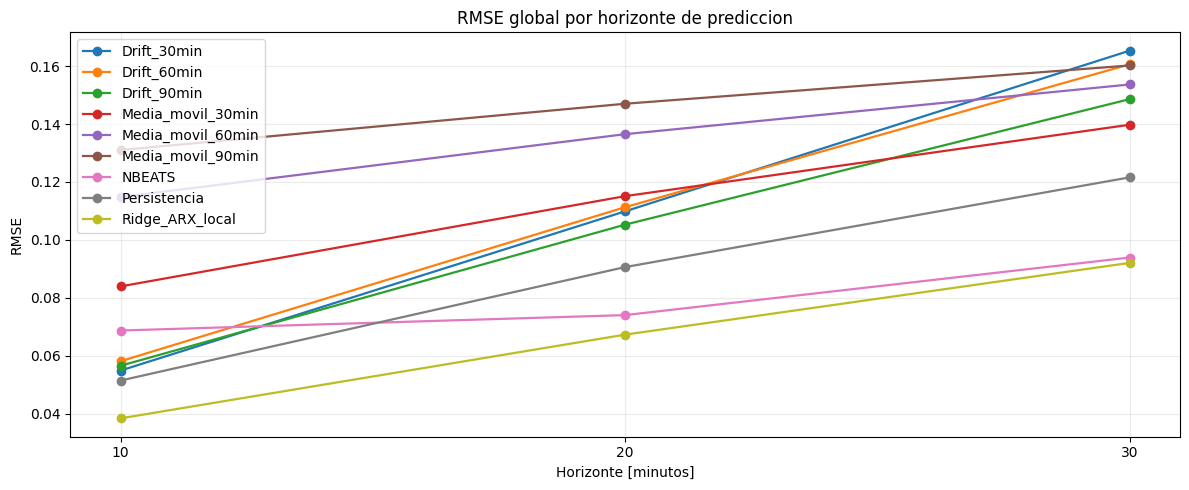

In [20]:
plot_df = lead_metrics_df[lead_metrics_df["segmento"] == "global"].copy()

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in plot_df.groupby("modelo"):
    model_df = model_df.sort_values("lead_minutes")
    ax.plot(model_df["lead_minutes"], model_df["RMSE"], marker="o", linewidth=1.6, label=model_name)

ax.set_title("RMSE global por horizonte de prediccion")
ax.set_xlabel("Horizonte [minutos]")
ax.set_ylabel("RMSE")
ax.set_xticks([10, 20, 30])
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_rmse_por_lead_global.png"), dpi=180, bbox_inches="tight")
plt.show()


## Metricas en condiciones criticas

Se calculan metricas en cuatro subconjuntos:

- `precipitacion_gt_0`: hay lluvia;
- `lluvia_1h_alta`: acumulado 1h alto;
- `nivel_p90`: nivel observado alto;
- `delta_positivo_alto`: subida rapida.

Estas condiciones permiten saber si N-BEATS mejora donde realmente importa para alerta temprana.


In [21]:
def condition_masks(eval_df):
    masks = {}
    masks["todos"] = pd.Series(True, index=eval_df.index)
    masks["precipitacion_gt_0"] = eval_df[RAIN_COL] > 0

    positive_rain_1h = eval_df.loc[eval_df["lluvia_1h"] > 0, "lluvia_1h"]
    if len(positive_rain_1h) > 0:
        rain_1h_threshold = positive_rain_1h.quantile(0.75)
        masks["lluvia_1h_alta"] = eval_df["lluvia_1h"] >= rain_1h_threshold
    else:
        masks["lluvia_1h_alta"] = pd.Series(False, index=eval_df.index)

    level_threshold = eval_df["actual"].quantile(0.90)
    masks["nivel_p90"] = eval_df["actual"] >= level_threshold

    positive_delta = eval_df.loc[eval_df["delta_nivel"] > 0, "delta_nivel"]
    if len(positive_delta) > 0:
        delta_threshold = positive_delta.quantile(0.90)
        masks["delta_positivo_alto"] = eval_df["delta_nivel"] >= delta_threshold
    else:
        masks["delta_positivo_alto"] = pd.Series(False, index=eval_df.index)

    return masks


condition_rows = []
condition_lead_rows = []

for (model_name, segment_name), eval_df in predictions.items():
    masks = condition_masks(eval_df)

    for condition_name, mask in masks.items():
        subset = eval_df.loc[mask]
        metrics = compute_metrics(subset["actual"].values, subset["pred"].values)
        metrics["modelo"] = model_name
        metrics["segmento"] = segment_name
        metrics["condicion"] = condition_name
        condition_rows.append(metrics)

        for lead_minutes, lead_df in subset.groupby("lead_minutes"):
            lead_metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
            lead_metrics["modelo"] = model_name
            lead_metrics["segmento"] = segment_name
            lead_metrics["condicion"] = condition_name
            lead_metrics["lead_minutes"] = int(lead_minutes)
            condition_lead_rows.append(lead_metrics)

condition_metrics_df = pd.DataFrame(condition_rows)
condition_metrics_df = condition_metrics_df[
    ["modelo", "segmento", "condicion", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
].sort_values(["condicion", "segmento", "RMSE", "modelo"]).reset_index(drop=True)

condition_lead_metrics_df = pd.DataFrame(condition_lead_rows)
condition_lead_metrics_df = condition_lead_metrics_df[
    ["modelo", "segmento", "condicion", "lead_minutes", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
].sort_values(["condicion", "segmento", "lead_minutes", "RMSE", "modelo"]).reset_index(drop=True)

display(condition_metrics_df)
display(condition_lead_metrics_df)

condition_metrics_path = os.path.join(REPORTS_DIR, "15_metricas_condiciones.csv")
condition_lead_metrics_path = os.path.join(REPORTS_DIR, "15_metricas_condiciones_por_lead.csv")

condition_metrics_df.to_csv(condition_metrics_path, index=False)
condition_lead_metrics_df.to_csv(condition_lead_metrics_path, index=False)

print("Metricas por condicion guardadas en:", condition_metrics_path)
print("Metricas por condicion y lead guardadas en:", condition_lead_metrics_path)


,modelo,segmento,condicion,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,Ridge_ARX_local,2021,delta_positivo_alto,660,0.097684,0.237522,0.874127,16.322941,18.495318,-4.847849e-02,0.874127
1,NBEATS,2021,delta_positivo_alto,660,0.130104,0.297604,0.802393,26.947537,29.635267,-3.038356e-02,0.802393
2,Drift_90min,2021,delta_positivo_alto,660,0.133802,0.360590,0.709896,18.441053,24.160886,-1.277150e-01,0.709896
3,Drift_30min,2021,delta_positivo_alto,660,0.132951,0.364800,0.703083,17.505161,22.790753,-1.051381e-01,0.703083
4,Drift_60min,2021,delta_positivo_alto,660,0.134549,0.369550,0.695300,18.076670,23.638055,-1.229347e-01,0.695300
...,...,...,...,...,...,...,...,...,...,...,...
85,Media_movil_30min,2025,todos,13071,0.018791,0.114649,0.716320,1.495967,1.544882,-4.054778e-05,0.716320
86,Drift_60min,2025,todos,13071,0.019021,0.121308,0.682413,1.526764,1.547082,-7.650524e-07,0.682413
87,Drift_30min,2025,todos,13071,0.017658,0.127768,0.647685,1.379561,1.377561,-1.530105e-06,0.647685
88,Media_movil_60min,2025,todos,13071,0.023645,0.131424,0.627231,2.021827,2.038024,-6.043914e-05,0.627231


,modelo,segmento,condicion,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,Ridge_ARX_local,2021,delta_positivo_alto,10,220,0.060937,0.145320,0.952883,11.239182,12.155745,-0.021700,0.952883
1,Drift_90min,2021,delta_positivo_alto,10,220,0.075552,0.199527,0.911176,12.113505,14.614651,-0.068712,0.911176
2,Drift_30min,2021,delta_positivo_alto,10,220,0.077690,0.201834,0.909110,11.531545,13.649014,-0.041066,0.909110
3,Drift_60min,2021,delta_positivo_alto,10,220,0.075521,0.202881,0.908165,11.826113,14.218373,-0.062224,0.908165
4,Persistencia,2021,delta_positivo_alto,10,220,0.087797,0.222755,0.889292,13.790468,16.609835,-0.087797,0.889292
...,...,...,...,...,...,...,...,...,...,...,...,...
265,Media_movil_60min,2025,todos,30,4357,0.027484,0.147395,0.531121,2.405173,2.408772,-0.000074,0.531121
266,Media_movil_90min,2025,todos,30,4357,0.029623,0.150483,0.511274,2.770393,2.731002,-0.000094,0.511274
267,Drift_90min,2025,todos,30,4357,0.027651,0.151980,0.501500,2.337472,2.380300,-0.000002,0.501500
268,Drift_60min,2025,todos,30,4357,0.028512,0.163939,0.419964,2.313716,2.323928,-0.000001,0.419964


Metricas por condicion guardadas en: /data/students/federico.moran/reports/15_metricas_condiciones.csv
Metricas por condicion y lead guardadas en: /data/students/federico.moran/reports/15_metricas_condiciones_por_lead.csv


In [22]:
# Modificado por Codex 2026-05-28:
# esta celda ahora genera la tabla critica t+30 aunque las metricas por condicion
# se hayan calculado solamente por segmento. Si no existen filas globales, se
# reconstruyen agregando 2021 y 2025 desde `predictions`.
conditions_for_paper = ["precipitacion_gt_0", "lluvia_1h_alta", "nivel_p90", "delta_positivo_alto"]
metric_columns = [
    "modelo",
    "segmento",
    "condicion",
    "lead_minutes",
    "n",
    "MAE",
    "RMSE",
    "R2",
    "MAPE (%)",
    "sMAPE (%)",
    "Bias",
    "NSE",
]

paper_condition_global_t30 = condition_lead_metrics_df[
    (condition_lead_metrics_df["segmento"] == "global")
    & (condition_lead_metrics_df["lead_minutes"] == 30)
    & (condition_lead_metrics_df["condicion"].isin(conditions_for_paper))
].copy()

if paper_condition_global_t30.empty:
    paper_condition_rows = []

    for model_name in sorted({model_name for model_name, _ in predictions.keys()}):
        model_frames = [
            eval_df
            for (candidate_model, _), eval_df in predictions.items()
            if candidate_model == model_name
        ]

        if not model_frames:
            continue

        model_eval_df = pd.concat(model_frames, axis=0).sort_index()
        masks = condition_masks(model_eval_df)

        for condition_name in conditions_for_paper:
            mask = masks.get(condition_name)
            if mask is None:
                continue

            subset = model_eval_df.loc[mask & (model_eval_df["lead_minutes"] == 30)].copy()
            if len(subset) == 0:
                continue

            metrics = compute_metrics(subset["actual"].values, subset["pred"].values)
            metrics["modelo"] = model_name
            metrics["segmento"] = "global"
            metrics["condicion"] = condition_name
            metrics["lead_minutes"] = 30
            paper_condition_rows.append(metrics)

    paper_condition_t30 = pd.DataFrame(paper_condition_rows)
    if len(paper_condition_t30) > 0:
        paper_condition_t30 = paper_condition_t30[metric_columns]
else:
    paper_condition_t30 = paper_condition_global_t30[metric_columns].copy()

paper_condition_t30 = (
    paper_condition_t30
    .sort_values(["condicion", "RMSE", "modelo"])
    .reset_index(drop=True)
)

display(paper_condition_t30)

paper_condition_path = os.path.join(REPORTS_DIR, "15_tabla_condiciones_t30.csv")
paper_condition_t30.to_csv(paper_condition_path, index=False)
print("Tabla condiciones t+30 guardada en:", paper_condition_path)


,modelo,segmento,condicion,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,Ridge_ARX_local,global,delta_positivo_alto,30,265,0.209790,0.407063,0.692886,21.277832,25.260679,-0.155336,0.692886
1,NBEATS,global,delta_positivo_alto,30,265,0.238867,0.485764,0.562652,23.360253,24.805684,-0.136582,0.562652
2,Drift_30min,global,delta_positivo_alto,30,265,0.261384,0.555669,0.427720,22.755896,31.396676,-0.250331,0.427720
3,Drift_90min,global,delta_positivo_alto,30,265,0.271897,0.570085,0.397641,23.660470,32.876315,-0.266367,0.397641
4,Drift_60min,global,delta_positivo_alto,30,265,0.277840,0.579165,0.378300,23.765770,32.889198,-0.269050,0.378300
5,Persistencia,global,delta_positivo_alto,30,265,0.282373,0.591917,0.350622,24.015595,33.486699,-0.281488,0.350622
6,Media_movil_30min,global,delta_positivo_alto,30,265,0.305233,0.641816,0.236523,25.691555,36.422379,-0.301039,0.236523
7,Media_movil_60min,global,delta_positivo_alto,30,265,0.312441,0.653465,0.208555,26.756999,38.462886,-0.305817,0.208555
8,Media_movil_90min,global,delta_positivo_alto,30,265,0.317455,0.660446,0.191557,27.363342,39.567649,-0.307429,0.191557
9,Ridge_ARX_local,global,lluvia_1h_alta,30,141,0.464937,0.650283,0.602490,34.620493,35.262121,-0.091340,0.602490


Tabla condiciones t+30 guardada en: /data/students/federico.moran/reports/15_tabla_condiciones_t30.csv


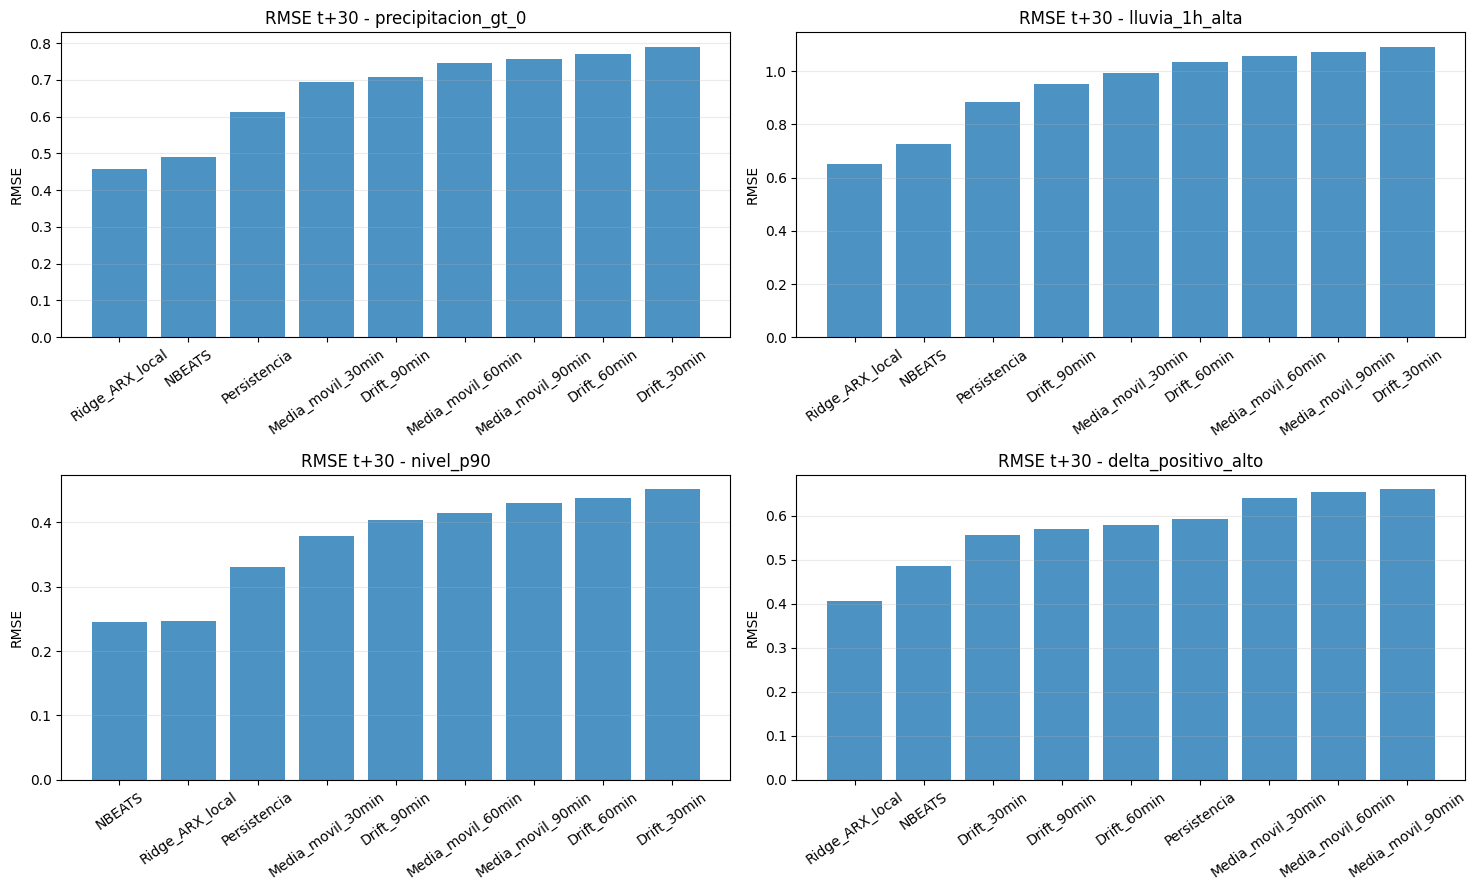

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
axes = axes.ravel()

for ax, condition_name in zip(axes, conditions_for_paper):
    plot_df = paper_condition_t30[paper_condition_t30["condicion"] == condition_name].copy()
    plot_df = plot_df.sort_values("RMSE")
    ax.bar(plot_df["modelo"], plot_df["RMSE"], color="tab:blue", alpha=0.8)
    ax.set_title(f"RMSE t+30 - {condition_name}")
    ax.set_ylabel("RMSE")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "03_rmse_condiciones_t30.png"), dpi=180, bbox_inches="tight")
plt.show()


## Figuras de eventos

Se generan figuras de eventos usando el instante de mayor subida positiva dentro de validacion. Para el paper conviene elegir manualmente 1 o 2 eventos representativos despues de revisar estas figuras.

La figura muestra predicciones a `t+30 min`, alineadas con el instante predicho.


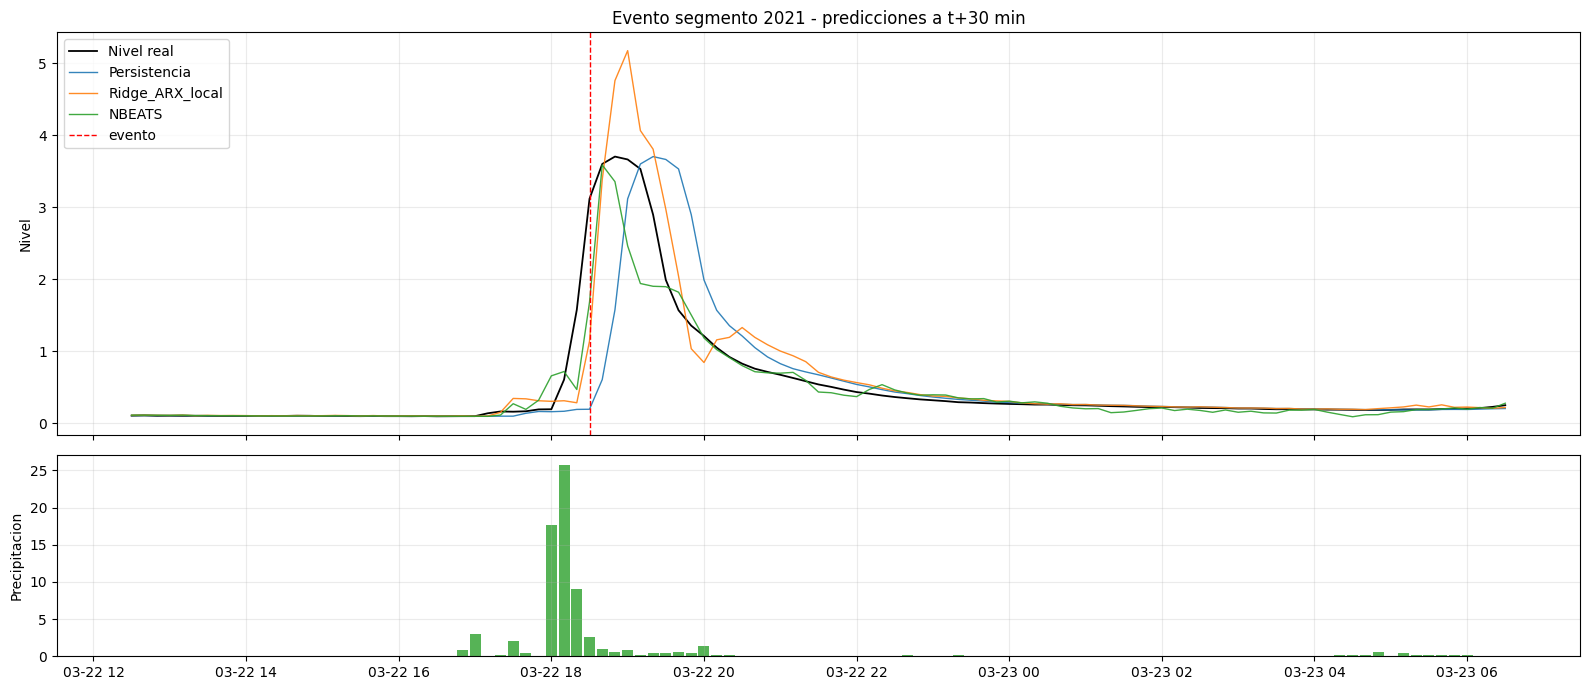

Evento: 2022-03-22 18:30:00
Figura: /data/students/federico.moran/figures/15_nbeats_vs_baselines_final/04_evento_2021_t30.png


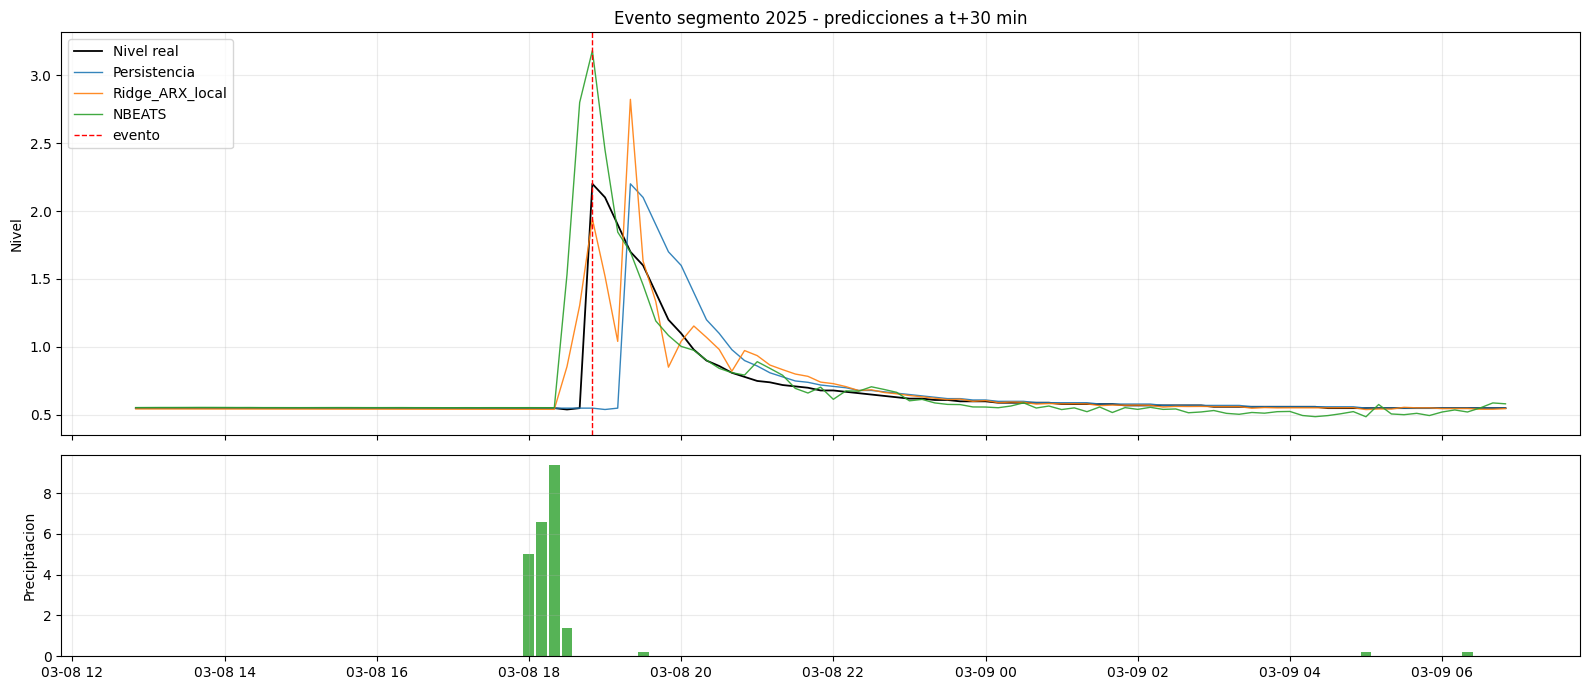

Evento: 2026-03-08 18:50:00
Figura: /data/students/federico.moran/figures/15_nbeats_vs_baselines_final/04_evento_2025_t30.png


In [24]:
def find_event_time(segment_name):
    context = context_for_segment(segment_name)
    test_start_time = split_info[segment_name]["test_start_time"]
    test_context = context[context.index >= test_start_time].copy()
    test_context = test_context.dropna(subset=["delta_nivel"])

    positive = test_context[test_context["delta_nivel"] > 0]
    if len(positive) == 0:
        return test_context["lluvia_1h"].idxmax()

    return positive["delta_nivel"].idxmax()


def plot_event(segment_name, models_to_plot=None, lead_minutes=30):
    if models_to_plot is None:
        models_to_plot = ["Persistencia", "Ridge_ARX_local", "NBEATS"]
        models_to_plot = [m for m in models_to_plot if (m, segment_name) in predictions]

    event_time = find_event_time(segment_name)
    start_time = event_time - pd.Timedelta(hours=ZOOM_HOURS_BEFORE)
    end_time = event_time + pd.Timedelta(hours=ZOOM_HOURS_AFTER)

    context = context_for_segment(segment_name)
    context_zoom = context[(context.index >= start_time) & (context.index <= end_time)]

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

    axes[0].plot(context_zoom.index, context_zoom["actual"], label="Nivel real", color="black", linewidth=1.3)

    for model_name in models_to_plot:
        eval_df = predictions.get((model_name, segment_name))
        if eval_df is None or eval_df.empty:
            continue

        model_plot = eval_df[
            (eval_df["lead_minutes"] == lead_minutes)
            & (eval_df["pred_time"] >= start_time)
            & (eval_df["pred_time"] <= end_time)
        ].sort_values("pred_time")

        axes[0].plot(model_plot["pred_time"], model_plot["pred"], label=model_name, linewidth=1.0, alpha=0.9)

    axes[0].axvline(event_time, color="red", linestyle="--", linewidth=1, label="evento")
    axes[0].set_title(f"Evento segmento {segment_name} - predicciones a t+{lead_minutes} min")
    axes[0].set_ylabel("Nivel")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="upper left")

    axes[1].bar(context_zoom.index, context_zoom[RAIN_COL], width=0.006, color="tab:green", alpha=0.8)
    axes[1].set_ylabel("Precipitacion")
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    fig_path = os.path.join(FIGURES_DIR, f"04_evento_{segment_name}_t{lead_minutes}.png")
    fig.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Evento:", event_time)
    print("Figura:", fig_path)


for segment_name in segment_names:
    plot_event(segment_name, lead_minutes=30)


## Exportacion de predicciones

Se guarda una tabla larga con todas las predicciones. Esto permite rehacer figuras del paper sin volver a entrenar el modelo.


## Lectura final para el paper

Al terminar de ejecutar el notebook, las tablas principales para escribir el paper son:

| Archivo | Uso |
|---|---|
| `15_tabla_principal_global.csv` | Comparacion global entre baselines y N-BEATS. |
| `15_tabla_principal_t30.csv` | Comparacion principal en el horizonte de 30 minutos. |
| `15_metricas_por_lead.csv` | Degradacion por lead time. |
| `15_tabla_condiciones_t30.csv` | Comparacion en condiciones criticas a 30 minutos. |
| `15_predicciones_long.csv` | Predicciones para rehacer figuras. |

La conclusion debe responder directamente:

```text
N-BEATS vale la pena frente a persistencia?
N-BEATS vale la pena frente a Ridge-ARX local?
N-BEATS mejora durante lluvia, nivel alto y subidas rapidas?
```

Si N-BEATS solo mejora globalmente pero no en condiciones criticas, la utilidad operacional es limitada. Si mejora especialmente en `delta_positivo_alto` o `lluvia_1h_alta`, entonces hay una justificacion fuerte para usar deep learning.


In [ ]:
# Exportacion final para intercambio con otro grupo de trabajo. Fue creada para compartir las predicciones con la gente de brasil
# Esta celda no recalcula modelos: solo guarda datos y predicciones ya generadas.

REQUESTED_EXPORT_DIR = r"G:\\Mi unidad\\Maestria - IA\\Tesis\\Proyectos\\Mburicao_Iberamia\\tests\\15_baselines_vs_nbeats"

# En Windows se usa exactamente la ruta solicitada. Si el notebook se ejecuta en Linux/JupyterHub,
# se usa la carpeta equivalente dentro de PROJECT_DIR para evitar crear una ruta invalida con 'G:\\'.
if os.name == "nt":
    EXPORT_DIR = REQUESTED_EXPORT_DIR
else:
    EXPORT_DIR = os.path.join(PROJECT_DIR, "tests", "15_baselines_vs_nbeats")

os.makedirs(EXPORT_DIR, exist_ok=True)


def dataframe_with_time_column(df):
    export_df = df.copy().reset_index()
    first_col = export_df.columns[0]
    if first_col != TIME_COL:
        export_df = export_df.rename(columns={first_col: TIME_COL})
    return export_df


def export_train_val_test_segment(segment_name):
    df_segment = segments[segment_name]
    train_end_time = split_info[segment_name]["train_end_time"]
    test_start_time = split_info[segment_name]["test_start_time"]

    export_df = df_segment.copy()
    export_df["split"] = np.select(
        [
            export_df.index < train_end_time,
            (export_df.index >= train_end_time) & (export_df.index < test_start_time),
        ],
        ["train", "validation"],
        default="test",
    )
    export_df = dataframe_with_time_column(export_df)

    preferred_cols = [TIME_COL, "split", TARGET_COL, RAIN_COL, "segmento"]
    remaining_cols = [col for col in export_df.columns if col not in preferred_cols]
    export_df = export_df[[col for col in preferred_cols if col in export_df.columns] + remaining_cols]

    path = os.path.join(EXPORT_DIR, f"train_val_test_{segment_name}.csv")
    export_df.to_csv(path, index=False)
    return path, len(export_df)


def export_prediction_file(model_name, segment_name, file_model_label):
    key = (model_name, segment_name)
    if key not in predictions:
        raise KeyError(
            f"No se encontraron predicciones para {key}. "
            "Ejecuta primero las celdas de entrenamiento y prediccion."
        )

    pred_df = predictions[key].copy()
    pred_df = pred_df.sort_values(["origin_time", "lead_minutes", "pred_time"]).reset_index(drop=True)

    preferred_cols = [
        "segmento",
        "modelo",
        "origin_time",
        "pred_time",
        "lead_step",
        "lead_minutes",
        "actual",
        "pred",
        RAIN_COL,
        "lluvia_1h",
        "delta_nivel",
    ]
    export_cols = [col for col in preferred_cols if col in pred_df.columns]
    export_cols += [col for col in pred_df.columns if col not in export_cols]
    pred_df = pred_df[export_cols]

    path = os.path.join(EXPORT_DIR, f"predicciones_test_{segment_name}_{file_model_label}.csv")
    pred_df.to_csv(path, index=False)
    return path, len(pred_df)


export_rows = []

for segment_name in ["2021", "2025"]:
    path, n_rows = export_train_val_test_segment(segment_name)
    export_rows.append({
        "archivo": os.path.basename(path),
        "filas": n_rows,
        "descripcion": f"Datos de train, validation y test del segmento {segment_name}.",
    })

for segment_name in ["2021", "2025"]:
    path, n_rows = export_prediction_file("Ridge_ARX_local", segment_name, "ridge_arx")
    export_rows.append({
        "archivo": os.path.basename(path),
        "filas": n_rows,
        "descripcion": f"Predicciones de test del segmento {segment_name} con Ridge-ARX local.",
    })

for segment_name in ["2021", "2025"]:
    path, n_rows = export_prediction_file("NBEATS", segment_name, "nbeats")
    export_rows.append({
        "archivo": os.path.basename(path),
        "filas": n_rows,
        "descripcion": f"Predicciones de test del segmento {segment_name} con N-BEATS.",
    })

readme_text = f"""# Exportacion de datos y predicciones - notebook 15

Directorio de exportacion usado por esta ejecucion:

`{EXPORT_DIR}`

Esta carpeta contiene los datos y predicciones generados por el notebook `15_nbeats_vs_baselines_final.ipynb` para compartirlos con otro grupo de trabajo.

## Archivos de datos train + validation + test

- `train_val_test_2021.csv`: observaciones completas del segmento 2021, indicando si cada fila pertenece a train, validation o test.
- `train_val_test_2025.csv`: observaciones completas del segmento 2025, indicando si cada fila pertenece a train, validation o test.

Columnas principales:

- `{TIME_COL}`: marca temporal de la observacion.
- `split`: indica si la fila pertenece a `train`, `validation` o `test`.
- `{TARGET_COL}`: nivel observado del cauce.
- `{RAIN_COL}`: precipitacion acumulada en el intervalo de 10 minutos.
- `segmento`: identificador del segmento temporal.

## Archivos de predicciones sobre test

- `predicciones_test_2021_ridge_arx.csv`: predicciones del modelo Ridge-ARX local sobre el test del segmento 2021.
- `predicciones_test_2025_ridge_arx.csv`: predicciones del modelo Ridge-ARX local sobre el test del segmento 2025.
- `predicciones_test_2021_nbeats.csv`: predicciones del modelo N-BEATS sobre el test del segmento 2021.
- `predicciones_test_2025_nbeats.csv`: predicciones del modelo N-BEATS sobre el test del segmento 2025.

Cada archivo de predicciones esta en formato largo: hay una fila por origen de prediccion, instante predicho y horizonte evaluado. Incluye los horizontes de 10, 20 y 30 minutos.

Columnas principales:

- `segmento`: segmento temporal (`2021` o `2025`).
- `modelo`: modelo que genero la prediccion.
- `origin_time`: ultimo instante observado antes de emitir la prediccion.
- `pred_time`: instante futuro que se predice.
- `lead_step`: horizonte expresado en pasos de 10 minutos.
- `lead_minutes`: horizonte expresado en minutos.
- `actual`: nivel observado en `pred_time`.
- `pred`: nivel predicho por el modelo.
- `{RAIN_COL}`: precipitacion observada en `pred_time`.
- `lluvia_1h`: lluvia acumulada de la ultima hora asociada a `pred_time`.
- `delta_nivel`: cambio observado del nivel en `pred_time` respecto al paso anterior.

## Nota metodologica

Los segmentos 2021 y 2025 se exportan por separado porque no se tratan como una unica serie temporal continua. Entre ambos periodos existe un intervalo sin observaciones, por lo que unirlos generaria continuidad temporal artificial.
"""

readme_path = os.path.join(EXPORT_DIR, "README.md")
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

export_summary_df = pd.DataFrame(export_rows)
display(export_summary_df)
print("Archivos exportados en:", EXPORT_DIR)
print("README:", readme_path)
